19:28:22 - cmdstanpy - INFO - Chain [1] start processing
19:28:22 - cmdstanpy - INFO - Chain [1] done processing


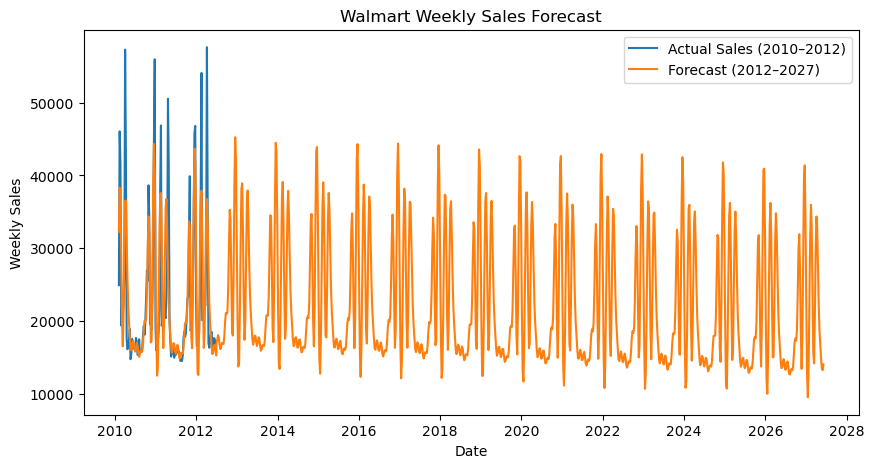

In [2]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

# -----------------------------
# 1. Load cleaned Walmart data
# -----------------------------
data = pd.read_csv("data_clean/walmart_clean.csv", parse_dates=["Date"])

# Focus on Store 1, Department 1
sales_data = data[
    (data["Store"] == 1) &
    (data["Dept"] == 1)
].sort_values("Date")

# -----------------------------
# 2. Use Actual Sales only
#    (2010 to July 2012)
# -----------------------------
training_data = sales_data[
    (sales_data["Date"] >= "2010-01-01") &
    (sales_data["Date"] <= "2012-07-01")
]

# Prepare data for Prophet
model_data = training_data[["Date", "Weekly_Sales"]]
model_data.columns = ["ds", "y"]

# -----------------------------
# 3. Train forecasting model
# -----------------------------
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)
model.fit(model_data)

# -----------------------------
# 4. Forecast to July 2027
# -----------------------------
future_dates = model.make_future_dataframe(periods=780, freq="W")
forecast = model.predict(future_dates)

# -----------------------------
# 5. Create business-friendly output
# -----------------------------
forecast_output = forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]]

forecast_output.columns = [
    "Date",
    "Forecast_Sales",
    "Forecast_Lower_Bound",
    "Forecast_Upper_Bound"
]

forecast_output.to_csv(
    "data_clean/forecast_store1_dept1.csv",
    index=False
)

# -----------------------------
# 6. Optional: Plot preview
# -----------------------------
plt.figure(figsize=(10, 5))
plt.plot(model_data["ds"], model_data["y"], label="Actual Sales (2010–2012)")
plt.plot(forecast_output["Date"], forecast_output["Forecast_Sales"], label="Forecast (2012–2027)")
plt.legend()
plt.title("Walmart Weekly Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.show()